# 🏨 Predicción de cancelación de reservas hoteleras
## Evolve Academy · Máster en Data Science & IA

**Caso práctico:** clasificación binaria con impacto en Revenue Management  
**Dataset:** Hotel Booking Demand — Antonio, Almeida & Nunes (2019)  
**Target:** `is_canceled`

### Objetivo de negocio

Construir un modelo que estime, **en el momento de la reserva**, la probabilidad de cancelación de una reserva hotelera. El resultado se utilizará como apoyo para priorizar acciones preventivas, teniendo en cuenta el equilibrio entre:

- Detectar reservas que finalmente se cancelarán.
- Evitar intervenciones innecesarias sobre clientes que no cancelarían.

> **Principio metodológico:** una variable solo se podrá utilizar si su valor está disponible en el momento definido para la predicción. La capacidad predictiva por sí sola no justifica incluir una variable.


## 0. Entorno y dependencias

El notebook está diseñado para ejecutarse de arriba abajo. Antes de la entrega se debe comprobar que todas las dependencias están disponibles en el entorno final.


In [1]:
# Si es necesario, instalar dependencias:
#%pip install pandas numpy matplotlib seaborn scikit-learn xgboost lightgbm optuna shap

import warnings
warnings.filterwarnings("ignore")

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    roc_auc_score, roc_curve, average_precision_score, accuracy_score, balanced_accuracy_score,
    precision_score, recall_score, f1_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    RocCurveDisplay, precision_recall_curve
)
from sklearn.model_selection import TimeSeriesSplit
from sklearn.base import clone

import optuna
import shap

# Modelos opcionales
import xgboost as xgb

optuna.logging.set_verbosity(optuna.logging.WARNING)

RANDOM_STATE = 42
TARGET = "is_canceled"

pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", "{:.4f}".format)

sns.set_theme(style="whitegrid", context="notebook")


## 1. Carga y primera inspección

El archivo debe estar disponible en la misma carpeta que el notebook o en la ruta indicada en `DATA_PATH`.


In [ ]:
# Localización robusta del dataset
DATA_CANDIDATES = [
    Path("../data/raw/reservas_hoteleras.csv"),
    Path("data/raw/reservas_hoteleras.csv"),
    Path("reservas_hoteleras.csv"),
    Path("../data/reservas_hoteleras.csv"),
    Path("data/reservas_hoteleras.csv"),
]

DATA_PATH = next((p for p in DATA_CANDIDATES if p.exists()), None)

if DATA_PATH is None:
    raise FileNotFoundError(
        "No se encontró 'reservas_hoteleras.csv'. "
        "Colócalo en ../data/raw/ o junto al notebook."
    )

df_raw = pd.read_csv(DATA_PATH)

print(f"Archivo: {DATA_PATH}")
print(f"Filas: {df_raw.shape[0]:,}")
print(f"Columnas: {df_raw.shape[1]:,}")
display(df_raw.head())
display(df_raw.dtypes.to_frame("dtype"))


In [3]:
def resumen_variables(df):
    resumen = pd.DataFrame({
        "dtype": df.dtypes,
        "nulos": df.isna().sum(),
        "pct_nulos": df.isna().mean() * 100,
        "n_unique": df.nunique(dropna=False)
    })
    return resumen.sort_values(["nulos", "n_unique"], ascending=[False, True])

display(resumen_variables(df_raw))

print("Duplicados completos:", df_raw.duplicated().sum())
print("\nDistribución del target:")
display(df_raw[TARGET].value_counts(dropna=False).to_frame("count"))

print(f"\nTasa de cancelación: {df_raw[TARGET].mean():.2%}")


,dtype,nulos,pct_nulos,n_unique
company,float64,112593,94.3069,353
agent,float64,16340,13.6862,334
country,str,488,0.4087,178
children,float64,4,0.0034,6
hotel,str,0,0.0000,2
is_canceled,int64,0,0.0000,2
is_repeated_guest,int64,0,0.0000,2
arrival_date_year,int64,0,0.0000,3
deposit_type,str,0,0.0000,3
reservation_status,str,0,0.0000,3


Duplicados completos: 31994

Distribución del target:


,count
is_canceled,
0,75166
1,44224



Tasa de cancelación: 37.04%


## 2. Definición del momento de predicción

### Escenario adoptado

La predicción se realiza **cuando la reserva se encuentra creada/confirmada**, utilizando únicamente la información disponible en ese instante.

Esta definición debe mantenerse durante todo el proyecto. Si cambiara el momento de predicción, también podrían cambiar las variables válidas, el tratamiento de nulos y la interpretación del modelo.

### Revisión inicial de posibles fugas de información

| Variable | Decisión inicial | Motivo |
|---|---|---|
| `reservation_status` | Excluir | Estado final de la reserva; revela información posterior. |
| `reservation_status_date` | Excluir | Fecha asociada al estado final. |
| `booking_changes` | Excluir inicialmente | El valor agregado puede incluir cambios posteriores a la creación. |
| `assigned_room_type` | Excluir inicialmente | No se garantiza que el valor final estuviera disponible en el instante inicial. |
| `days_in_waiting_list` | Revisar | Su validez depende de cuándo se realiza la predicción y de cuándo se confirma la reserva. |
| `previous_cancellations` | Mantener, sujeto a validación | Historial previo del cliente, potencialmente disponible en el momento de la reserva. |
| `adr` | Mantener, sujeto a validación | Precio medio diario que puede estar disponible al reservar; se revisará su interpretación. |

> Esta tabla es una hipótesis metodológica inicial. Las decisiones definitivas deben quedar justificadas en función del momento de predicción y de la documentación del dataset.


In [4]:
# Auditoría de variables relacionadas con el posible leakage
candidate_columns = [
    "reservation_status",
    "reservation_status_date",
    "booking_changes",
    "assigned_room_type",
    "days_in_waiting_list",
    "previous_cancellations",
    "adr"
]

available_candidates = [c for c in candidate_columns if c in df_raw.columns]

for col in available_candidates:
    print(f"\n### {col}")
    print("Tipo:", df_raw[col].dtype)
    print("Valores únicos:", df_raw[col].nunique(dropna=False))
    display(df_raw[col].value_counts(dropna=False).head(10).to_frame("count"))



### reservation_status
Tipo: str
Valores únicos: 3


,count
reservation_status,
Check-Out,75166
Canceled,43017
No-Show,1207



### reservation_status_date
Tipo: str
Valores únicos: 926


,count
reservation_status_date,
2015-10-21,1461
2015-07-06,805
2016-11-25,790
2015-01-01,763
2016-01-18,625
2015-07-02,469
2016-12-07,450
2015-12-18,423
2016-02-09,412



### booking_changes
Tipo: int64
Valores únicos: 21


...

,count
days_in_waiting_list,
0,115692
39,227
58,164
44,141
31,127
35,96
46,94
69,89
63,83



### previous_cancellations
Tipo: int64
Valores únicos: 15


,count
previous_cancellations,
0,112906
1,6051
2,116
3,65
24,48
11,35
4,31
26,26
25,25



### adr
Tipo: float64
Valores únicos: 8879


,count
adr,
62.0000,3754
75.0000,2715
90.0000,2473
65.0000,2418
0.0000,1959
80.0000,1889
95.0000,1661
120.0000,1607
100.0000,1573


In [5]:
# Comprobación de discrepancias entre habitación reservada y asignada
if {"reserved_room_type", "assigned_room_type"}.issubset(df_raw.columns):
    mismatch_rate = (
        df_raw["reserved_room_type"] != df_raw["assigned_room_type"]
    ).mean()
    print(f"Porcentaje de reservas con habitación reservada distinta de asignada: {mismatch_rate:.2%}")


Porcentaje de reservas con habitación reservada distinta de asignada: 12.49%


## 3. Limpieza inicial

Se revisan duplicados, valores imposibles e inconsistencias antes de modelizar.

**Duplicados completos:** se mantienen porque el dataset no incluye un identificador único de reserva. Dos registros idénticos pueden representar reservas distintas; eliminarlos automáticamente podría modificar artificialmente la distribución del target.

Los valores problemáticos se documentan primero. La imputación de variables se realizará dentro del pipeline de entrenamiento para evitar fugas durante el preprocesamiento.


In [ ]:
df = df_raw.copy()

# No se eliminan duplicados completos de forma automática.
# El dataset no proporciona un identificador de reserva y dos filas idénticas
# pueden corresponder a reservas reales distintas.
n_duplicates = df.duplicated().sum()

checks = {"duplicados_completos": n_duplicates}

if {"adults", "children", "babies"}.issubset(df.columns):
    checks["reservas_sin_huespedes"] = (
        (df["adults"].fillna(0) + df["children"].fillna(0) + df["babies"].fillna(0)) == 0
    ).sum()

if "adr" in df.columns:
    checks["adr_negativo"] = (df["adr"] < 0).sum()

display(pd.Series(checks, name="count").to_frame())


## 4. EDA orientado al negocio

Cada análisis debe responder a una pregunta y terminar con una conclusión accionable. Se muestran tanto tasas como volúmenes para evitar interpretar de forma aislada grupos con pocas observaciones.


In [7]:
def cancellation_summary(data, group_col):
    summary = (
        data.groupby(group_col, dropna=False)[TARGET]
        .agg(["count", "mean"])
        .rename(columns={"count": "reservas", "mean": "tasa_cancelacion"})
        .sort_values("tasa_cancelacion", ascending=False)
    )
    return summary

def plot_cancellation_rate(data, group_col, title, rotation=0):
    summary = cancellation_summary(data, group_col)
    ax = summary["tasa_cancelacion"].mul(100).plot(kind="bar", figsize=(10, 5))
    ax.set_title(title)
    ax.set_ylabel("Tasa de cancelación (%)")
    ax.set_xlabel(group_col)
    plt.xticks(rotation=rotation)
    plt.tight_layout()
    plt.show()
    display(summary)


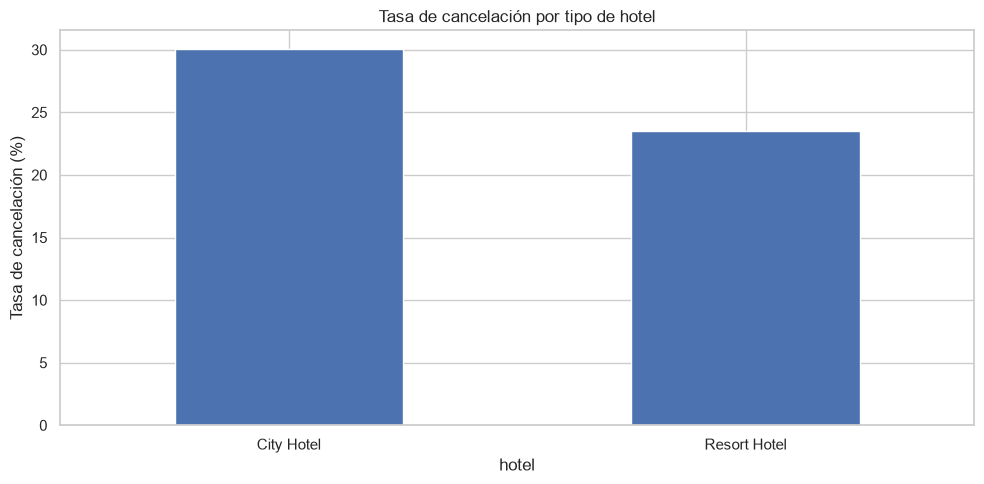

,reservas,tasa_cancelacion
hotel,,
City Hotel,53428,0.3004
Resort Hotel,33968,0.2348


In [8]:
# 4.1 Cancelación por hotel
plot_cancellation_rate(
    df,
    "hotel",
    "Tasa de cancelación por tipo de hotel"
)


,reservas,tasa_cancelacion
arrival_date_month,,
January,4693,0.2212
February,6098,0.2320
March,7513,0.2436
April,7908,0.3046
May,8355,0.2923
June,7765,0.3032
July,10057,0.3180
August,11257,0.3218
September,6690,0.2454


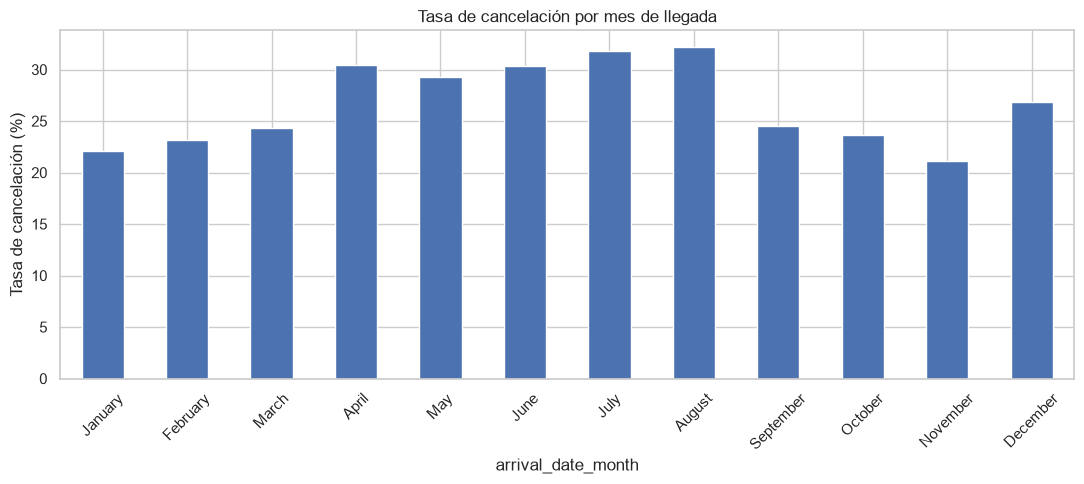

In [9]:
# 4.2 Cancelación por mes de llegada
if "arrival_date_month" in df.columns:
    month_order = [
        "January", "February", "March", "April", "May", "June",
        "July", "August", "September", "October", "November", "December"
    ]
    month_summary = cancellation_summary(df, "arrival_date_month").reindex(month_order)
    display(month_summary)

    ax = month_summary["tasa_cancelacion"].mul(100).plot(
        kind="bar", figsize=(11, 5)
    )
    ax.set_title("Tasa de cancelación por mes de llegada")
    ax.set_ylabel("Tasa de cancelación (%)")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()


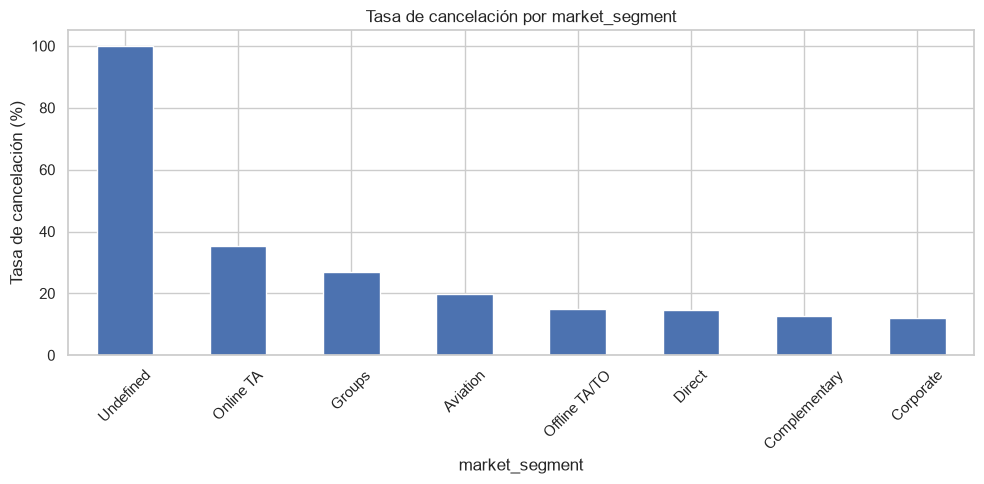

,reservas,tasa_cancelacion
market_segment,,
Undefined,2,1.0000
Online TA,51618,0.3535
Groups,4942,0.2701
Aviation,227,0.1982
Offline TA/TO,13889,0.1485
Direct,11804,0.1472
Complementary,702,0.1254
Corporate,4212,0.1211


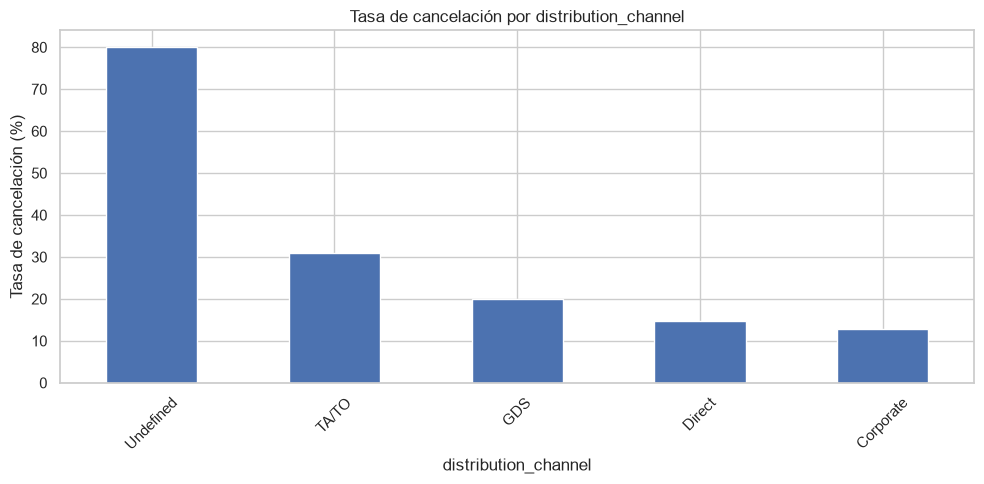

,reservas,tasa_cancelacion
distribution_channel,,
Undefined,5,0.8000
TA/TO,69141,0.3097
GDS,181,0.1989
Direct,12988,0.1482
Corporate,5081,0.1275


In [10]:
# 4.3 Cancelación por canal/segmento
for col in ["market_segment", "distribution_channel"]:
    if col in df.columns:
        plot_cancellation_rate(
            df,
            col,
            f"Tasa de cancelación por {col}",
            rotation=45
        )


,reservas,tasa_cancelacion
lead_time_group_eda,,
366+,565,0.4088
181-365,11200,0.3968
91-180,18243,0.3498
31-90,22744,0.3201
8-30,16340,0.2537
0-7,18304,0.0843


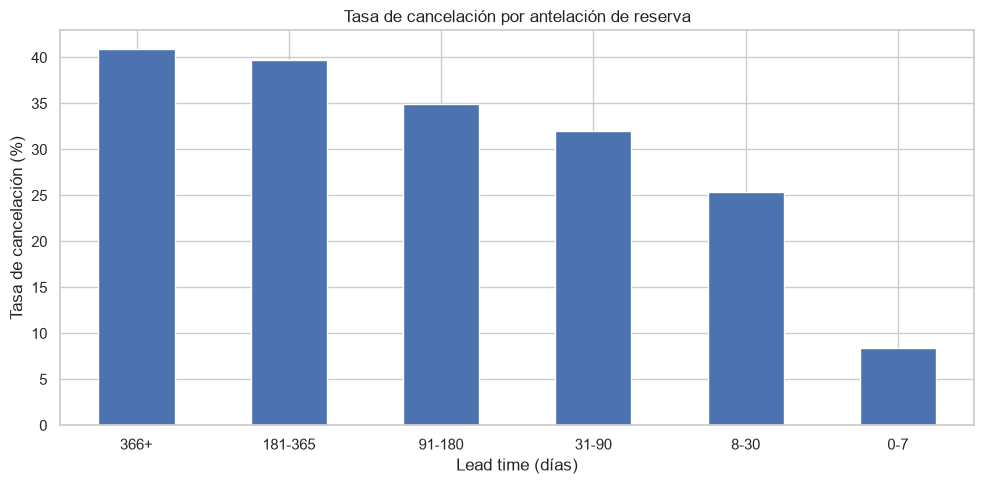

In [11]:
# 4.4 Lead time y cancelación
if "lead_time" in df.columns:
    bins = [-1, 7, 30, 90, 180, 365, np.inf]
    labels = ["0-7", "8-30", "31-90", "91-180", "181-365", "366+"]
    df["lead_time_group_eda"] = pd.cut(
        df["lead_time"], bins=bins, labels=labels
    )

    lead_summary = cancellation_summary(df, "lead_time_group_eda")
    display(lead_summary)

    fig, ax = plt.subplots(figsize=(10, 5))
    lead_summary["tasa_cancelacion"].mul(100).plot(kind="bar", ax=ax)
    ax.set_title("Tasa de cancelación por antelación de reserva")
    ax.set_ylabel("Tasa de cancelación (%)")
    ax.set_xlabel("Lead time (días)")
    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.show()


,count,mean,median,std,min,max
is_canceled,,,,,,
0,63371,102.0020,94.5000,51.3934,-6.3800,510.0000
1,24025,117.7725,109.8000,62.1492,0.0000,5400.0000


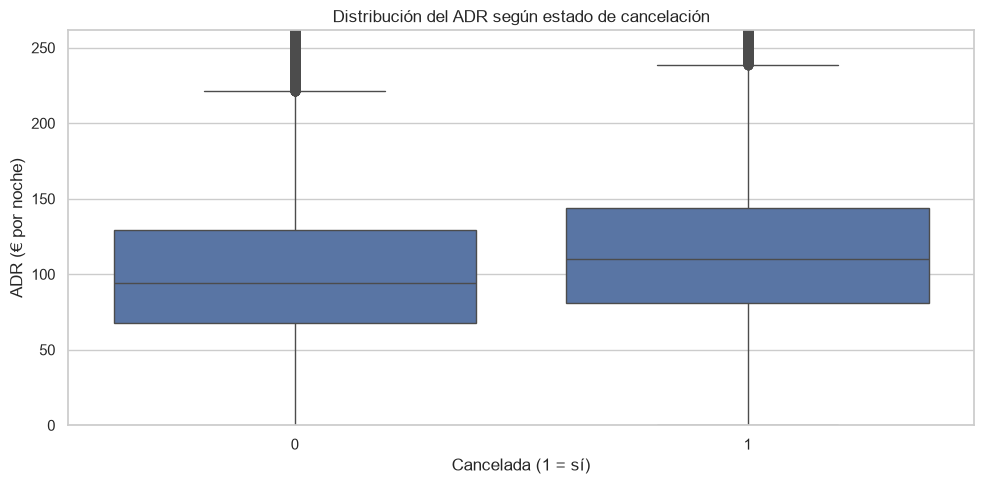

In [12]:
# 4.5 ADR entre reservas canceladas y no canceladas
if "adr" in df.columns:
    adr_summary = df.groupby(TARGET)["adr"].agg(
        ["count", "mean", "median", "std", "min", "max"]
    )
    display(adr_summary)

    plt.figure(figsize=(10, 5))
    sns.boxplot(data=df, x=TARGET, y="adr")
    plt.title("Distribución del ADR según estado de cancelación")
    plt.xlabel("Cancelada (1 = sí)")
    plt.ylabel("ADR (€ por noche)")
    plt.ylim(df["adr"].quantile(0.01), df["adr"].quantile(0.99))
    plt.tight_layout()
    plt.show()


Se detectaron 5 registros con el valor `Undefined` en la variable `distribution_channel` y 2 registros con este valor en `market_segment`. La revisión individual de estos registros mostró que se trata de observaciones reales con diferentes combinaciones de segmento de mercado y agente, por lo que no es posible determinar de forma inequívoca cuál debería ser su categoría original.

Cuatro de las cinco reservas con `distribution_channel = Undefined` están canceladas. Sin embargo, este porcentaje no se considera representativo, ya que se obtiene sobre únicamente 5 observaciones.

Por este motivo, se decidió conservar estos registros y mantener `Undefined` como una categoría propia, evitando tanto la eliminación de observaciones como la imputación arbitraria de una categoría. El posible efecto de estos casos sobre el modelo se considera limitado debido a su frecuencia extremadamente baja.


Valores Undefined: se mantienen como categoría. Solo aparecen en 5 reservas (distribution_channel) y 2 (market_segment); aunque 4/5 están canceladas, el tamaño muestral es demasiado reducido para extraer conclusiones. No se imputan ni eliminan.

## 5. Feature Engineering

### Features propuestas

- `total_guests`: tamaño total del grupo.
- `total_nights`: duración total de la estancia.
- `has_children`: indicador de presencia de niños o bebés.


In [24]:
def add_features(data):
    out = data.copy()

    if {"adults", "children", "babies"}.issubset(out.columns):
        out["total_guests"] = (
            out["adults"].fillna(0)
            + out["children"].fillna(0)
            + out["babies"].fillna(0)
        )
        out["has_children"] = (
            (out["children"].fillna(0) + out["babies"].fillna(0)) > 0
        ).astype(int)

    if {"stays_in_weekend_nights", "stays_in_week_nights"}.issubset(out.columns):
        out["total_nights"] = (
            out["stays_in_weekend_nights"].fillna(0)
            + out["stays_in_week_nights"].fillna(0)
        )

    return out

df = add_features(df)
display(df.head())


,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,meal,country,market_segment,distribution_channel,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,reserved_room_type,assigned_room_type,booking_changes,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date,lead_time_group_eda,total_guests,has_children,total_nights
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,0.0000,0,BB,PRT,Direct,Direct,0,0,0,C,C,3,No Deposit,NaN,NaN,0,Transient,0.0000,0,0,Check-Out,2015-07-01,181-365,2.0000,0,0
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,0.0000,0,BB,PRT,Direct,Direct,0,0,0,C,C,4,No Deposit,NaN,NaN,0,Transient,0.0000,0,0,Check-Out,2015-07-01,366+,2.0000,0,0
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,0.0000,0,BB,GBR,Direct,Direct,0,0,0,A,C,0,No Deposit,NaN,NaN,0,Transient,75.0000,0,0,Check-Out,2015-07-02,0-7,1.0000,0,1
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,0.0000,0,BB,GBR,Corporate,Corporate,0,0,0,A,A,0,No Deposit,304.0000,NaN,0,Transient,75.0000,0,0,Check-Out,2015-07-02,8-30,1.0000,0,1
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,0.0000,0,BB,GBR,Online TA,TA/TO,0,0,0,A,A,0,No Deposit,240.0000,NaN,0,Transient,98.0000,0,1,Check-Out,2015-07-03,8-30,2.0000,0,2


## 6. Preparación del dataset para modelización

Se eliminan variables que no son válidas para el escenario definido. Las decisiones deben quedar documentadas y revisarse si el profesor proporciona una interpretación distinta del momento de predicción.

`lead_time_group_eda` se elimina porque se creó únicamente para el EDA. Si posteriormente se considera útil para el modelo, se deberá crear de forma controlada y justificar su uso.


In [25]:
LEAKAGE_COLUMNS = [
    "reservation_status",
    "reservation_status_date",
    "booking_changes",
    "assigned_room_type",
    "lead_time_group_eda"
]

# A partir de este punto se mantiene una estrategia más conservadora con variables
# que sí están disponibles en el momento de la reserva y no son una consecuencia
# del resultado final de la reserva.
CONSERVATIVE_EXCLUDE = [
    "days_in_waiting_list"
]

DROP_COLUMNS = [
    col for col in LEAKAGE_COLUMNS + CONSERVATIVE_EXCLUDE
    if col in df.columns
]

MODEL_COLUMNS = [
    "hotel",
    "lead_time",
    "arrival_date_year",
    "arrival_date_month",
    "arrival_date_week_number",
    "arrival_date_day_of_month",
    "stays_in_weekend_nights",
    "stays_in_week_nights",
    "adults",
    "children",
    "babies",
    "meal",
    "country",
    "market_segment",
    "distribution_channel",
    "is_repeated_guest",
    "previous_cancellations",
    "previous_bookings_not_canceled",
    "reserved_room_type",
    "deposit_type",
    "customer_type",
    "required_car_parking_spaces",
    "adr",
    "total_of_special_requests",

    # Variables derivadas
    "total_guests",
    "has_children",
    "total_nights",

    # Variable objetivo
    "is_canceled"
]

model_df = df[MODEL_COLUMNS].copy()

print("Columnas excluidas:")
print(DROP_COLUMNS)

print("Columnas seleccionadas para modelización:")
print(model_df.columns.tolist())

print("\nDimensiones para modelización:", model_df.shape)


Columnas excluidas:
['reservation_status', 'reservation_status_date', 'booking_changes', 'assigned_room_type', 'lead_time_group_eda', 'days_in_waiting_list']
Columnas seleccionadas para modelización:
['hotel', 'lead_time', 'arrival_date_year', 'arrival_date_month', 'arrival_date_week_number', 'arrival_date_day_of_month', 'stays_in_weekend_nights', 'stays_in_week_nights', 'adults', 'children', 'babies', 'meal', 'country', 'market_segment', 'distribution_channel', 'is_repeated_guest', 'previous_cancellations', 'previous_bookings_not_canceled', 'reserved_room_type', 'deposit_type', 'customer_type', 'required_car_parking_spaces', 'adr', 'total_of_special_requests', 'total_guests', 'has_children', 'total_nights', 'is_canceled']

Dimensiones para modelización: (87396, 28)


## 7. Orden temporal y partición train/test

El dataset no proporciona necesariamente la fecha exacta de creación de cada reserva. Por ello, se utiliza la fecha de llegada como aproximación temporal y se documenta esta limitación.

Se reserva el periodo más reciente para el test final. El test no se utiliza para elegir hiperparámetros ni para seleccionar el modelo ganador.


In [26]:
def create_arrival_date(data):
    month_map = {
        "January": 1, "February": 2, "March": 3, "April": 4,
        "May": 5, "June": 6, "July": 7, "August": 8,
        "September": 9, "October": 10, "November": 11, "December": 12
    }

    month_num = data["arrival_date_month"].map(month_map)

    return pd.to_datetime(
        {
            "year": data["arrival_date_year"],
            "month": month_num,
            "day": data["arrival_date_day_of_month"]
        },
        errors="coerce"
    )

required_date_cols = [
    "arrival_date_year",
    "arrival_date_month",
    "arrival_date_day_of_month"
]

if all(c in model_df.columns for c in required_date_cols):
    model_df["_arrival_date"] = create_arrival_date(model_df)
    model_df = model_df.sort_values("_arrival_date").reset_index(drop=True)
else:
    raise ValueError("No están disponibles todas las columnas necesarias para crear la fecha de llegada.")

# La fecha auxiliar se utiliza para ordenar, no como predictor directo.
model_df = model_df.drop(columns=["_arrival_date"])


In [27]:
# Split temporal por posición.
# El porcentaje es una decisión inicial y debe comprobarse observando las fechas resultantes.
split_index = int(len(model_df) * 0.75)

train_df = model_df.iloc[:split_index].copy()
test_df = model_df.iloc[split_index:].copy()

X_train = train_df.drop(columns=[TARGET])
y_train = train_df[TARGET]

X_test = test_df.drop(columns=[TARGET])
y_test = test_df[TARGET]

print("Train:", X_train.shape, " | Test:", X_test.shape)
print("Tasa target train:", y_train.mean())
print("Tasa target test:", y_test.mean())


Train: (65547, 27)  | Test: (21849, 27)
Tasa target train: 0.25142264329412484
Tasa target test: 0.345324728820541


## 8. Preprocesamiento

El preprocesamiento se ajusta únicamente sobre el conjunto de entrenamiento mediante `Pipeline` y `ColumnTransformer`.

- Variables numéricas: imputación por mediana y estandarización.
- Variables categóricas: imputación por moda y One-Hot Encoding.
- Las variables categóricas desconocidas en test se ignoran para evitar errores de ejecución.


In [28]:
numeric_features = X_train.select_dtypes(include=["number", "bool"]).columns.tolist()
categorical_features = X_train.select_dtypes(exclude=["number", "bool"]).columns.tolist()

numeric_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_pipeline, numeric_features),
        ("cat", categorical_pipeline, categorical_features)
    ],
    remainder="drop"
)

print("Variables numéricas:", len(numeric_features))
print("Variables categóricas:", len(categorical_features))


Variables numéricas: 18
Variables categóricas: 9


## 9. Baseline: Regresión Logística

La regresión logística constituye la referencia interpretable del proyecto. Se utiliza como baseline antes de evaluar modelos más complejos.


In [29]:
baseline_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(
        max_iter=2000,
        class_weight=None,
        random_state=RANDOM_STATE
    ))
])

baseline_pipeline.fit(X_train, y_train)

baseline_proba = baseline_pipeline.predict_proba(X_test)[:, 1]
baseline_pred = (baseline_proba >= 0.5).astype(int)

balanced_logit_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(
        max_iter=2000,
        class_weight="balanced",
        random_state=RANDOM_STATE
    ))
])

balanced_logit_pipeline.fit(X_train, y_train)

balanced_logit_proba = balanced_logit_pipeline.predict_proba(X_test)[:, 1]
balanced_logit_pred = (balanced_logit_proba >= 0.5).astype(int)


def confusion_metrics(y_true, y_pred):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
    return {
        "falsos_positivos": int(fp),
        "falsos_negativos": int(fn),
        "verdaderos_positivos": int(tp),
        "verdaderos_negativos": int(tn),
    }


def evaluate_model(y_true, y_pred, y_proba, model_name):
    metrics = confusion_metrics(y_true, y_pred)
    return pd.Series({
        "model": model_name,
        "roc_auc": roc_auc_score(y_true, y_proba),
        "pr_auc": average_precision_score(y_true, y_proba),
        "accuracy": accuracy_score(y_true, y_pred),
        "balanced_accuracy": balanced_accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        **metrics
    })


baseline_results = evaluate_model(
    y_test, baseline_pred, baseline_proba, "Logistic Regression"
)
balanced_results = evaluate_model(
    y_test, balanced_logit_pred, balanced_logit_proba, "Logistic Regression Balanced"
)

display(baseline_results.to_frame().T)
display(balanced_results.to_frame().T)

print("Logistic Regression")
print(classification_report(y_test, baseline_pred, zero_division=0))
print("\nLogistic Regression Balanced")
print(classification_report(y_test, balanced_logit_pred, zero_division=0))


,model,roc_auc,pr_auc,accuracy,balanced_accuracy,precision,recall,f1,falsos_positivos,falsos_negativos,verdaderos_positivos,verdaderos_negativos
0,Logistic Regression,0.8107,0.6897,0.7475,0.7144,0.6420,0.6076,0.6243,2556,2961,4584,11748


,model,roc_auc,pr_auc,accuracy,balanced_accuracy,precision,recall,f1,falsos_positivos,falsos_negativos,verdaderos_positivos,verdaderos_negativos
0,Logistic Regression Balanced,0.8100,0.6817,0.6441,0.7071,0.4917,0.9111,0.6387,7106,671,6874,7198


Logistic Regression
              precision    recall  f1-score   support

           0       0.80      0.82      0.81     14304
           1       0.64      0.61      0.62      7545

    accuracy                           0.75     21849
   macro avg       0.72      0.71      0.72     21849
weighted avg       0.74      0.75      0.75     21849


Logistic Regression Balanced
              precision    recall  f1-score   support

           0       0.91      0.50      0.65     14304
           1       0.49      0.91      0.64      7545

    accuracy                           0.64     21849
   macro avg       0.70      0.71      0.64     21849
weighted avg       0.77      0.64      0.65     21849



## 10. Modelo adicional: Random Forest

Se incorpora Random Forest como primer modelo no lineal. La comparación debe considerar no solo el resultado de las métricas, sino también la complejidad y la interpretabilidad.


In [30]:
rf_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(
        n_estimators=300,
        random_state=RANDOM_STATE,
        n_jobs=-1,
        class_weight=None
    ))
])

rf_pipeline.fit(X_train, y_train)

rf_proba = rf_pipeline.predict_proba(X_test)[:, 1]
rf_pred = (rf_proba >= 0.5).astype(int)

rf_results = evaluate_model(
    y_test, rf_pred, rf_proba, "Random Forest"
)

display(rf_results.to_frame().T)


,model,roc_auc,pr_auc,accuracy,balanced_accuracy,precision,recall,f1,falsos_positivos,falsos_negativos,verdaderos_positivos,verdaderos_negativos
0,Random Forest,0.8159,0.6664,0.7377,0.6677,0.6868,0.4417,0.5377,1520,4212,3333,12784


## 11. Optimización con Optuna

Optuna se utiliza para explorar hiperparámetros de un modelo de boosting. La función objetivo utiliza validación temporal dentro del conjunto de entrenamiento.

El test final se mantiene separado y no participa en la optimización.


In [31]:
# División temporal interna de train para validación durante la optimización
inner_split = int(len(X_train) * 0.75)

X_inner_train = X_train.iloc[:inner_split].copy()
y_inner_train = y_train.iloc[:inner_split].copy()

X_inner_valid = X_train.iloc[inner_split:].copy()
y_inner_valid = y_train.iloc[inner_split:].copy()


In [ ]:
# La optimización se realiza sobre una única transformación ajustada con el train interno.
# Así evitamos repetir el One-Hot Encoding e imputación en cada trial.
preprocessor_optuna = clone(preprocessor)
X_inner_train_transformed = preprocessor_optuna.fit_transform(
    X_inner_train, y_inner_train
)
X_inner_valid_transformed = preprocessor_optuna.transform(
    X_inner_valid
)

if hasattr(X_inner_train_transformed, "toarray"):
    X_inner_train_transformed = X_inner_train_transformed.toarray()
if hasattr(X_inner_valid_transformed, "toarray"):
    X_inner_valid_transformed = X_inner_valid_transformed.toarray()

def build_xgb_pipeline(params):
    return Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", xgb.XGBClassifier(
        objective="binary:logistic",
        eval_metric="logloss",
        tree_method="hist",
        random_state=RANDOM_STATE,
        n_jobs=-1,
        **params
        ))
    ])

def build_xgb_model(params):
    return xgb.XGBClassifier(
        objective="binary:logistic",
        eval_metric="logloss",
        tree_method="hist",
        random_state=RANDOM_STATE,
        n_jobs=-1,
        **params
    )

def objective(trial):
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 150, 600),
        "max_depth": trial.suggest_int("max_depth", 3, 8),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.20, log=True),
        "subsample": trial.suggest_float("subsample", 0.70, 1.00),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.70, 1.00),
        "min_child_weight": trial.suggest_int("min_child_weight", 1, 10),
        "reg_lambda": trial.suggest_float("reg_lambda", 1e-2, 10.0, log=True)
    }

    model = build_xgb_model(params)
    model.fit(X_inner_train_transformed, y_inner_train)

    valid_proba = model.predict_proba(X_inner_valid_transformed)[:, 1]
    return roc_auc_score(y_inner_valid, valid_proba)

N_TRIALS = 12

study = optuna.create_study(
    direction="maximize",
    sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE)
)

study.optimize(objective, n_trials=N_TRIALS, show_progress_bar=False)

print(f"Trials ejecutados: {len(study.trials)}")
print(f"Mejor AUC de validación: {study.best_value:.4f}")
print("Mejores parámetros:")
display(pd.Series(study.best_params).to_frame("value"))


In [33]:
optimized_xgb_pipeline = build_xgb_pipeline(study.best_params)
optimized_xgb_pipeline.fit(X_train, y_train)

xgb_proba = optimized_xgb_pipeline.predict_proba(X_test)[:, 1]
xgb_pred = (xgb_proba >= 0.5).astype(int)

xgb_results = evaluate_model(
    y_test, xgb_pred, xgb_proba, "Optimized XGBoost"
)

display(xgb_results.to_frame().T)


,model,roc_auc,pr_auc,accuracy,balanced_accuracy,precision,recall,f1,falsos_positivos,falsos_negativos,verdaderos_positivos,verdaderos_negativos
0,Optimized XGBoost,0.8303,0.6962,0.7495,0.6958,0.6784,0.5221,0.5901,1867,3606,3939,12437


In [34]:
fitted_model = optimized_xgb_pipeline.named_steps["model"]
fitted_preprocessor = optimized_xgb_pipeline.named_steps["preprocessor"]

X_test_transformed = fitted_preprocessor.transform(X_test)

if hasattr(X_test_transformed, "toarray"):
    X_test_transformed = X_test_transformed.toarray()

booster = fitted_model.get_booster()

print("Dimensiones X_test transformado:", X_test_transformed.shape)
print("Número de variables del Booster:", booster.num_features())
print(
    "Número de nombres de variables:",
    len(booster.feature_names) if booster.feature_names else None
)
print(
    "Primeros nombres del Booster:",
    booster.feature_names[:5] if booster.feature_names else None
)

Dimensiones X_test transformado: (21849, 230)
Número de variables del Booster: 230
Número de nombres de variables: None
Primeros nombres del Booster: None


## 12. Comparación de modelos

Las métricas se presentan juntas, pero la selección debe justificarse desde el problema de negocio. Un modelo con más recall puede detectar más cancelaciones, mientras que un modelo con más precision puede generar menos intervenciones innecesarias.


In [35]:
results = pd.DataFrame([
    baseline_results,
    balanced_results,
    rf_results,
    xgb_results
]).reset_index(drop=True)

display(results.sort_values("roc_auc", ascending=False))


,model,roc_auc,pr_auc,accuracy,balanced_accuracy,precision,recall,f1,falsos_positivos,falsos_negativos,verdaderos_positivos,verdaderos_negativos
3,Optimized XGBoost,0.8303,0.6962,0.7495,0.6958,0.6784,0.5221,0.5901,1867,3606,3939,12437
2,Random Forest,0.8159,0.6664,0.7377,0.6677,0.6868,0.4417,0.5377,1520,4212,3333,12784
0,Logistic Regression,0.8107,0.6897,0.7475,0.7144,0.6420,0.6076,0.6243,2556,2961,4584,11748
1,Logistic Regression Balanced,0.8100,0.6817,0.6441,0.7071,0.4917,0.9111,0.6387,7106,671,6874,7198


## 13. Optimización del umbral con criterio de negocio

En clasificación con clases desbalanceadas, el umbral no debe elegirse por costumbre. El valor 0.5 solo es un punto de partida, pero en Revenue Management el umbral debe reflejar el coste operativo de actuar o no actuar.

En este caso, un falso negativo puede ser más costoso que un falso positivo: perder una cancelación prevista suele ser más perjudicial que contactar a un cliente que finalmente no cancela. Por eso se suele optimizar un umbral mediante validación temporal y una regla de negocio.

La idea práctica es:

- ajustar el modelo sobre train
- elegir el umbral sobre un conjunto de validación interno
- evaluar el umbral final solo sobre el test temporal
- comparar la utilidad del modelo con una relación de costes: costo de FP frente a costo de FN



In [ ]:
# ============================================================
# Selección del umbral con una hipótesis de costes
# ============================================================
# Hipótesis ilustrativa: FN cuesta 3 veces más que FP.
# El coste real debe validarse con Revenue Management.
cost_fp = 1.0
cost_fn = 3.0

# Usamos el modelo optimizado sobre la validación interna.
validation_model = build_xgb_model(study.best_params)
validation_model.fit(X_inner_train_transformed, y_inner_train)
valid_proba = validation_model.predict_proba(X_inner_valid_transformed)[:, 1]

threshold_rows = []

for threshold in np.linspace(0.10, 0.90, 17):
    pred = (valid_proba >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(
        y_inner_valid, pred, labels=[0, 1]
    ).ravel()

    precision = precision_score(y_inner_valid, pred, zero_division=0)
    recall = recall_score(y_inner_valid, pred, zero_division=0)
    f1 = f1_score(y_inner_valid, pred, zero_division=0)

    expected_cost = fp * cost_fp + fn * cost_fn

    threshold_rows.append({
        "threshold": threshold,
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "expected_cost": expected_cost,
        "falsos_positivos": int(fp),
        "falsos_negativos": int(fn),
        "verdaderos_positivos": int(tp),
        "verdaderos_negativos": int(tn)
    })

threshold_results = pd.DataFrame(threshold_rows)

best_idx = threshold_results["expected_cost"].idxmin()
selected_threshold = float(threshold_results.loc[best_idx, "threshold"])

print(
    f"Umbral seleccionado en validación: {selected_threshold:.2f} "
    f"(hipótesis FN={cost_fn:.0f}×FP)"
)

plt.figure(figsize=(10, 5))
plt.plot(
    threshold_results["threshold"],
    threshold_results["expected_cost"],
    marker="o",
    linewidth=2
)
plt.axvline(
    selected_threshold,
    linestyle="--",
    label=f"Umbral seleccionado = {selected_threshold:.2f}"
)
plt.xlabel("Umbral")
plt.ylabel("Coste esperado")
plt.title("Selección del umbral con una hipótesis de costes")
plt.legend()
plt.tight_layout()
plt.show()

# Evaluación final en el test temporal.
selected_pred = (xgb_proba >= selected_threshold).astype(int)
selected_results = evaluate_model(
    y_test,
    selected_pred,
    xgb_proba,
    f"Optimized XGBoost @ {selected_threshold:.2f}"
)

display(selected_results.to_frame().T)


## 14. Interpretabilidad: qué señales utiliza el modelo

La interpretabilidad se utiliza para entender **qué variables contribuyen a las predicciones**, no para afirmar causalidad.

Se combinan dos perspectivas:

- **Importancia global de XGBoost:** resume qué variables utiliza el modelo con mayor frecuencia/peso según su criterio interno.
- **SHAP:** mide la contribución de cada variable a la predicción de una observación concreta y permite estudiar el conjunto del test.

Para evitar un análisis innecesariamente pesado, el summary plot de SHAP se calcula sobre una muestra reproducible del test. Las explicaciones locales se calculan para las reservas de **mayor y menor riesgo predicho**, seleccionadas dinámicamente.


In [ ]:
# Importancia global de XGBoost
fitted_preprocessor = optimized_xgb_pipeline.named_steps["preprocessor"]
fitted_model = optimized_xgb_pipeline.named_steps["model"]

feature_names = np.asarray(fitted_preprocessor.get_feature_names_out())
importances = np.asarray(fitted_model.feature_importances_)

importance_df = (
    pd.DataFrame({
        "feature": feature_names,
        "importance": importances
    })
    .sort_values("importance", ascending=False)
)

display(importance_df.head(15))

plot_df = importance_df.head(10).sort_values("importance")

plt.figure(figsize=(10, 6))
plt.barh(plot_df["feature"], plot_df["importance"])
plt.title("Importancia global de variables — XGBoost")
plt.xlabel("Importancia")
plt.ylabel("Variable")
plt.tight_layout()
plt.show()


In [ ]:
# SHAP sobre una muestra reproducible del test
X_test_transformed = fitted_preprocessor.transform(X_test)

if hasattr(X_test_transformed, "toarray"):
    X_test_transformed = X_test_transformed.toarray()

feature_names = np.asarray(
    fitted_preprocessor.get_feature_names_out()
)

SHAP_SAMPLE_SIZE = min(1000, len(X_test_transformed))
shap_sample_positions = np.random.default_rng(RANDOM_STATE).choice(
    len(X_test_transformed),
    size=SHAP_SAMPLE_SIZE,
    replace=False
)

explainer = shap.TreeExplainer(
    fitted_model,
    feature_perturbation="tree_path_dependent"
)

shap_values_sample = explainer.shap_values(
    X_test_transformed[shap_sample_positions]
)

shap_importance = (
    pd.DataFrame({
        "feature": feature_names,
        "mean_abs_shap": np.abs(shap_values_sample).mean(axis=0)
    })
    .sort_values("mean_abs_shap", ascending=False)
)

display(shap_importance.head(15))

shap.summary_plot(
    shap_values_sample,
    X_test_transformed[shap_sample_positions],
    feature_names=feature_names,
    max_display=15,
    show=False
)
plt.title("SHAP summary — muestra del test")
plt.tight_layout()
plt.show()


### Explicación de dos reservas concretas

Se seleccionan automáticamente las reservas con **mayor** y **menor probabilidad predicha de cancelación**. Esto evita depender de posiciones o índices fijados manualmente.

Los valores mostrados proceden de las variables originales; las columnas one-hot solo se utilizan internamente para calcular SHAP.


In [ ]:
# Selección dinámica de extremos de riesgo
high_risk_position = int(np.argmax(xgb_proba))
low_risk_position = int(np.argmin(xgb_proba))

print(
    f"Mayor riesgo: posición {high_risk_position}, "
    f"índice original {X_test.iloc[high_risk_position].name}, "
    f"probabilidad = {xgb_proba[high_risk_position]:.2%}"
)
print(
    f"Menor riesgo: posición {low_risk_position}, "
    f"índice original {X_test.iloc[low_risk_position].name}, "
    f"probabilidad = {xgb_proba[low_risk_position]:.2%}"
)

local_positions = [high_risk_position, low_risk_position]
local_shap_values = explainer.shap_values(
    X_test_transformed[local_positions]
)

def local_shap_table(position_in_local_array, original_position, top_n=10):
    values = local_shap_values[position_in_local_array]

    table = pd.DataFrame({
        "feature": feature_names,
        "shap": values,
        "abs_shap": np.abs(values)
    })

    table = table.sort_values(
        "abs_shap",
        ascending=False
    ).head(top_n)

    # Añadimos el valor original cuando la variable transformada
    # corresponde directamente a una variable numérica.
    original_row = X_test.iloc[original_position]

    readable_values = []
    for feature in table["feature"]:
        raw_name = feature.replace("num__", "").replace("cat__", "")
        if raw_name in X_test.columns:
            readable_values.append(original_row[raw_name])
        else:
            readable_values.append("categoría")

    table["valor_original"] = readable_values
    table["direccion"] = np.where(
        table["shap"] > 0,
        "↑ riesgo",
        "↓ riesgo"
    )

    return table[
        ["feature", "valor_original", "shap", "direccion"]
    ]

print("\nRESERVA DE MAYOR RIESGO")
display(local_shap_table(0, high_risk_position))

print("\nRESERVA DE MENOR RIESGO")
display(local_shap_table(1, low_risk_position))


**Lectura:** SHAP explica cómo distintas señales empujan la predicción de cada reserva hacia mayor o menor riesgo. No implica que esas variables sean causas de la cancelación.

En particular, una categoría one-hot con valor `0` significa que **esa categoría no está presente en esa reserva**; no debe interpretarse como que el cliente pertenece a dicha categoría.


In [ ]:
# Curva ROC del modelo final
fpr, tpr, _ = roc_curve(y_test, xgb_proba)
roc_auc = roc_auc_score(y_test, xgb_proba)

plt.figure(figsize=(7, 6))
plt.plot(
    fpr,
    tpr,
    label=f"XGBoost (AUC = {roc_auc:.3f})",
    linewidth=2.5
)
plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Sin capacidad de discriminación"
)
plt.xlabel("Tasa de falsos positivos (FPR)")
plt.ylabel("Tasa de verdaderos positivos (TPR)")
plt.title("Curva ROC — Predicción de cancelaciones")
plt.legend(loc="lower right")
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()

print(f"ROC-AUC en test temporal: {roc_auc:.4f}")


## 15. Conclusiones de negocio

El modelo permite asignar una probabilidad de cancelación a cada reserva antes de la llegada. El valor operativo no está únicamente en el AUC, sino en utilizar ese riesgo para **priorizar acciones**.

### Principales señales observadas

- **Lead time:** una mayor antelación aparece asociada a un mayor riesgo de cancelación.
- **Peticiones especiales:** un mayor número de peticiones aparece asociado a menor riesgo en el modelo.
- **Parking:** solicitar plazas de parking aparece asociado a menor riesgo, aunque la disponibilidad temporal de esta variable debe confirmarse con negocio.
- **Deposit type:** `Non Refund` presenta una asociación elevada con cancelación en este dataset. El resultado es contraintuitivo y no debe interpretarse causalmente; requiere validación con negocio.
- **País, segmento y canal:** muestran diferencias relevantes, pero deben interpretarse junto con el resto de variables y teniendo en cuenta el tamaño de cada grupo.

### Del score a la acción

El umbral utilizado en este notebook parte de una **hipótesis ilustrativa de coste FN = 3 × FP**. No representa un coste real del hotel. En producción debería estimarse con Revenue Management y contrastarse con la capacidad operativa del equipo.

Una posible aplicación sería trabajar con bandas de riesgo y acciones progresivas: seguimiento normal para riesgo bajo, recordatorios para riesgo medio y revisión proactiva para riesgo alto.

### Próximos pasos

1. Confirmar con negocio qué variables están realmente disponibles al crear la reserva.
2. Estimar costes reales de falsos positivos y falsos negativos.
3. Validar las probabilidades y el umbral en periodos posteriores.
4. Probar las acciones en un piloto con grupo de control.
5. Medir el impacto económico —por ejemplo, margen recuperado— además de las métricas del modelo.


In [ ]:
# Tabla comparativa final
xgb_pred_015 = (xgb_proba >= 0.15).astype(int)

xgb_015_results = evaluate_model(
    y_test,
    xgb_pred_015,
    xgb_proba,
    "XGBoost @ threshold 0.15"
)

comparison = pd.DataFrame([
    baseline_results,
    balanced_results,
    rf_results,
    xgb_results,
    selected_results,
    xgb_015_results
])

comparison = comparison[
    [
        "model",
        "roc_auc",
        "pr_auc",
        "accuracy",
        "precision",
        "recall",
        "f1",
        "verdaderos_positivos",
        "verdaderos_negativos",
        "falsos_positivos",
        "falsos_negativos"
    ]
].copy()

comparison = comparison.rename(columns={
    "model": "Modelo",
    "roc_auc": "ROC-AUC",
    "pr_auc": "PR-AUC",
    "accuracy": "Accuracy",
    "precision": "Precision",
    "recall": "Recall",
    "f1": "F1",
    "verdaderos_positivos": "TP",
    "verdaderos_negativos": "TN",
    "falsos_positivos": "FP",
    "falsos_negativos": "FN"
})

comparison[
    ["ROC-AUC", "PR-AUC", "Accuracy", "Precision", "Recall", "F1"]
] = (
    comparison[
        ["ROC-AUC", "PR-AUC", "Accuracy", "Precision", "Recall", "F1"]
    ] * 100
).round(2)

display(comparison)
